# Notebook 03: Wildfire Clustering Around Lake Tahoe

**Obstacle-Aware Clustering for Geographic Data**

This notebook applies the obstacle-aware k-Means algorithm to real-world wildfire occurrence data around Lake Tahoe. The analysis is organized into two tiers to clearly isolate the contributions of each component:

- **Tier 1 (Spatial Only)**: Compares standard k-Means on $(x, y)$ against the obstacle-aware algorithm on $(x, y, s)$ with $\gamma = 0$. This isolates the effect of the arc-length parameter without any attribute confounding.

- **Tier 2 (Spatial + Attributes)**: Adds fire size and cause type to the feature vector, engaging all three weight parameters ($\alpha$, $\beta$, $\gamma$). This demonstrates the full dual-domain capability.

**Applied story**: Define fire management zones around the lake that are spatially connected (fires in the same zone are reachable without going around the lake) and — in Tier 2 — behaviorally similar (fires share similar size and cause profiles).

---

## 1. Setup

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
from scipy.integrate import IntegrationWarning
import warnings
warnings.filterwarnings('ignore', category=IntegrationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sqlite3
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from scipy.optimize import dual_annealing
from obstacle_clustering.optimization import objective_function

# Our custom package
from obstacle_clustering import (
    SplineBoundary, ObstacleKMeans,
    optimize_weights, objective_surface, attribute_separation,
    plot_clusters, plot_comparison
)

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 2. Loading the Lake Tahoe Boundary

We load the cleaned boundary coordinates saved in Notebook 02 and fit the `SplineBoundary` for arc-length computation.

In [2]:
# Load boundary from Notebook 02
boundary_df = pd.read_csv('../data/boundaries/lake_tahoe_boundary.csv')
lon_boundary = boundary_df['longitude'].values
lat_boundary = boundary_df['latitude'].values

# Fit spline boundary
boundary = SplineBoundary(x_coords=lon_boundary, y_coords=lat_boundary)

L = boundary.total_arc_length()
print(f'Lake Tahoe boundary: {len(lon_boundary)} vertices')
print(f'Total arc length: {L:.4f} degrees')

# Sample for plotting
spline_pts = boundary.sample_boundary(n_points=500)

Lake Tahoe boundary: 269 vertices
Total arc length: 1.2027 degrees


## 3. Loading Wildfire Data

The [Fire Program Analysis Fire-Occurrence Database (FPA FOD)](https://www.fs.usda.gov/rds/archive/catalog/RDS-2013-0009.6) is a national database of wildfires reported in the United States from 1992 to 2020. We query the SQLite database for fires in the Lake Tahoe area.

**Important**: The FPA FOD SQLite file is not included in this repository due to its size (~2 GB). To reproduce this analysis:
1. Download `FPA_FOD_20221014.sqlite` from the [USFS Research Data Archive](https://www.fs.usda.gov/rds/archive/catalog/RDS-2013-0009.6)
2. Place it in the `data/raw/` directory

In [3]:
# Connect to the FPA FOD SQLite database
db_path = '../data/raw/fires.sqlite'  # adjust path if needed
conn = sqlite3.connect(db_path)

# Query fires in the Lake Tahoe area
query = """
    SELECT LATITUDE, LONGITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
           NWCG_CAUSE_CLASSIFICATION, FIRE_YEAR, DISCOVERY_DOY
    FROM Fires
    WHERE LATITUDE BETWEEN 38.85 AND 39.35
      AND LONGITUDE BETWEEN -120.25 AND -119.85
"""

fires_raw = pd.read_sql_query(query, conn)
conn.close()

print(f'Total fires in Lake Tahoe area: {len(fires_raw)}')
print(f'Year range: {fires_raw["FIRE_YEAR"].min()} - {fires_raw["FIRE_YEAR"].max()}')
print(f'\nCause breakdown:')
print(fires_raw['NWCG_GENERAL_CAUSE'].value_counts().to_string())

Total fires in Lake Tahoe area: 1888
Year range: 1992 - 2020

Cause breakdown:
NWCG_GENERAL_CAUSE
Recreation and ceremony                       500
Missing data/not specified/undetermined       423
Natural                                       374
Smoking                                       181
Arson/incendiarism                             97
Misuse of fire by a minor                      87
Debris and open burning                        86
Equipment and vehicle use                      78
Power generation/transmission/distribution     44
Fireworks                                      11
Other causes                                    6
Railroad operations and maintenance             1


## 4. Data Cleaning and Feature Engineering

We prepare the data for clustering in several steps:

1. **Filter out "Missing data/not specified/undetermined" cause entries** — these don't contribute meaningful attribute information
2. **Encode cause as binary**: Natural (lightning) vs. Human (all other known causes) — this parallels the NWCG classification and creates a clean attribute for separation analysis
3. **Project each fire onto the lake boundary** to compute its arc-length parameter $s$
4. **Normalize features** so that geographic coordinates and fire size are on comparable scales with $s$

In [4]:
# --- Step 1: Filter out missing cause data ---
fires = fires_raw[
    fires_raw['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined'
].copy()
print(f'Fires after filtering missing cause: {len(fires)}')

# --- Step 2: Encode cause as binary ---
# Natural = lightning; Human = all other known causes
fires['cause_binary'] = (
    fires['NWCG_GENERAL_CAUSE'].apply(lambda x: 0 if x == 'Natural' else 1)
)

print(f'\nCause classification:')
print(f"  Natural (lightning): {(fires['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires['cause_binary'] == 1).sum()}")

print(f'\nFire size statistics:')
print(fires['FIRE_SIZE'].describe())

Fires after filtering missing cause: 1465

Cause classification:
  Natural (lightning): 374
  Human-caused:        1091

Fire size statistics:
count    1465.000000
mean        9.381433
std       156.742888
min         0.010000
25%         0.100000
50%         0.100000
75%         0.100000
max      4222.000000
Name: FIRE_SIZE, dtype: float64


In [5]:
# --- Step 3: Project each fire onto the lake boundary ---
#This may take several minutes
print('Projecting fire locations onto lake boundary...')
t_values = []
s_values = []

n_fires = len(fires)
for idx, (_, row) in enumerate(fires.iterrows()):
    if idx % 200 == 0:
        print(f'  {idx}/{n_fires} ({100*idx/n_fires:.0f}%)')
    t_proj, s_proj = boundary.project_point(row['LONGITUDE'], row['LATITUDE'])
    t_values.append(t_proj)
    s_values.append(s_proj)

fires['t_param'] = t_values
fires['s_param'] = s_values

print(f'Projection complete: {n_fires} fires projected')
print(f's range: [{fires["s_param"].min():.4f}, {fires["s_param"].max():.4f}]')

Projecting fire locations onto lake boundary...
  0/1465 (0%)
  200/1465 (14%)
  400/1465 (27%)
  600/1465 (41%)
  800/1465 (55%)
  1000/1465 (68%)
  1200/1465 (82%)
  1400/1465 (96%)
Projection complete: 1465 fires projected
s range: [0.0069, 0.9980]


### Fire Size Distribution

Fire sizes in the FPA FOD span many orders of magnitude (from tiny spot fires to thousands of acres). We examine the distribution to decide on an appropriate transformation for clustering.

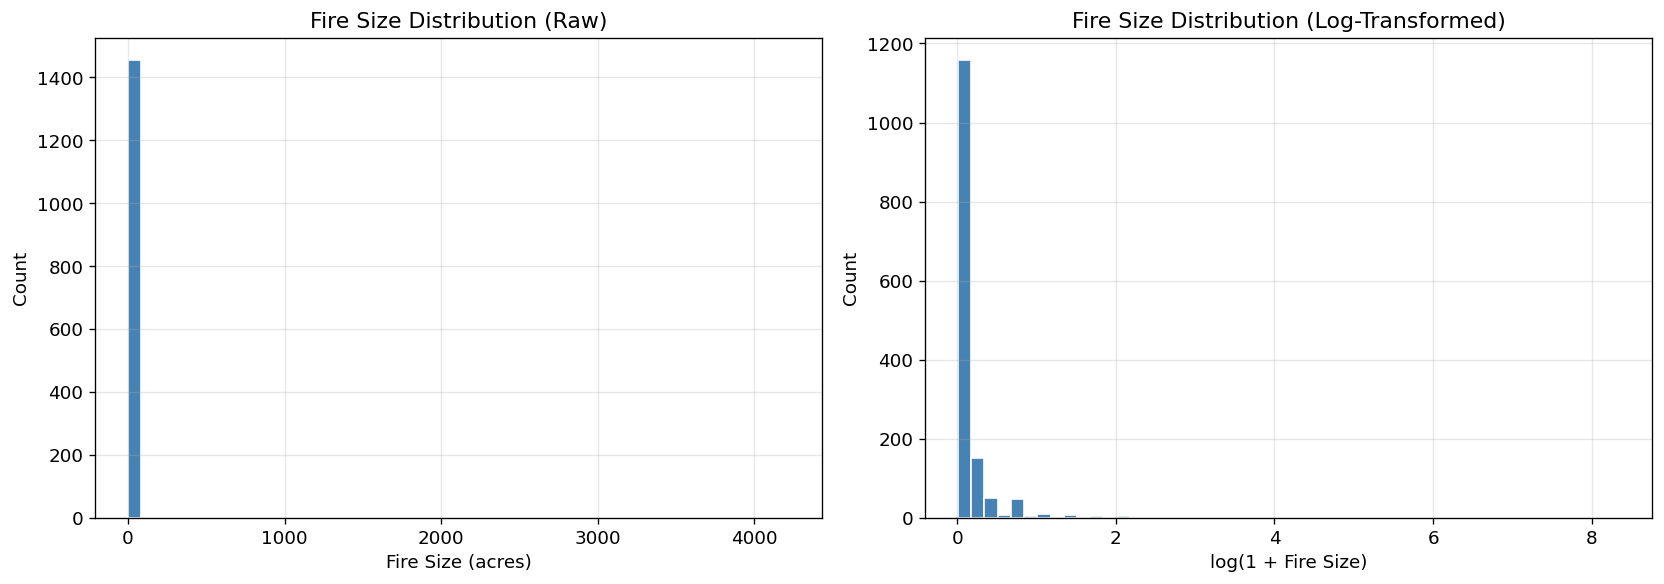

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
ax = axes[0]
ax.hist(fires['FIRE_SIZE'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Fire Size (acres)')
ax.set_ylabel('Count')
ax.set_title('Fire Size Distribution (Raw)')
ax.grid(True, alpha=0.3)

# Log-transformed
ax = axes[1]
ax.hist(np.log1p(fires['FIRE_SIZE']), bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('log(1 + Fire Size)')
ax.set_ylabel('Count')
ax.set_title('Fire Size Distribution (Log-Transformed)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Use log-transformed fire size for clustering
fires['fire_size_log'] = np.log1p(fires['FIRE_SIZE'])

In [7]:
# --- Step 4: Normalize features ---
# Geographic coordinates: Min-Max scale to [0, 1]
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(fires[['LONGITUDE', 'LATITUDE']].values)

# Fire size (log): Min-Max scale to [0, 1]
scaler_size = MinMaxScaler()
fire_size_scaled = scaler_size.fit_transform(fires[['fire_size_log']].values)

# s is already in [0, 1]
# cause_binary is already 0 or 1

# Assemble feature matrix: [x_scaled, y_scaled, s, fire_size_scaled, cause_binary]
X = np.column_stack([
    xy_scaled,                          # columns 0, 1: geographic
    fires['s_param'].values,            # column 2: arc-length
    fire_size_scaled.ravel(),           # column 3: fire size (normalized)
    fires['cause_binary'].values        # column 4: cause type
])

feature_names = ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']
print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_names}')
print(f'\nFirst 5 rows:')
print(np.array2string(X[:5], precision=4, suppress_small=True))

Feature matrix shape: (1465, 5)
Features: ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

First 5 rows:
[[0.9395 0.4711 0.6338 0.0474 0.    ]
 [0.9687 0.3394 0.6989 0.0102 0.    ]
 [0.9514 0.3917 0.6663 0.0102 0.    ]
 [0.1661 0.3167 0.026  0.0102 1.    ]
 [0.4955 0.1822 0.8678 0.0102 1.    ]]


## 5. Visualizing the Raw Data

Before clustering, we examine the spatial distribution of fires around the lake, colored by cause type.

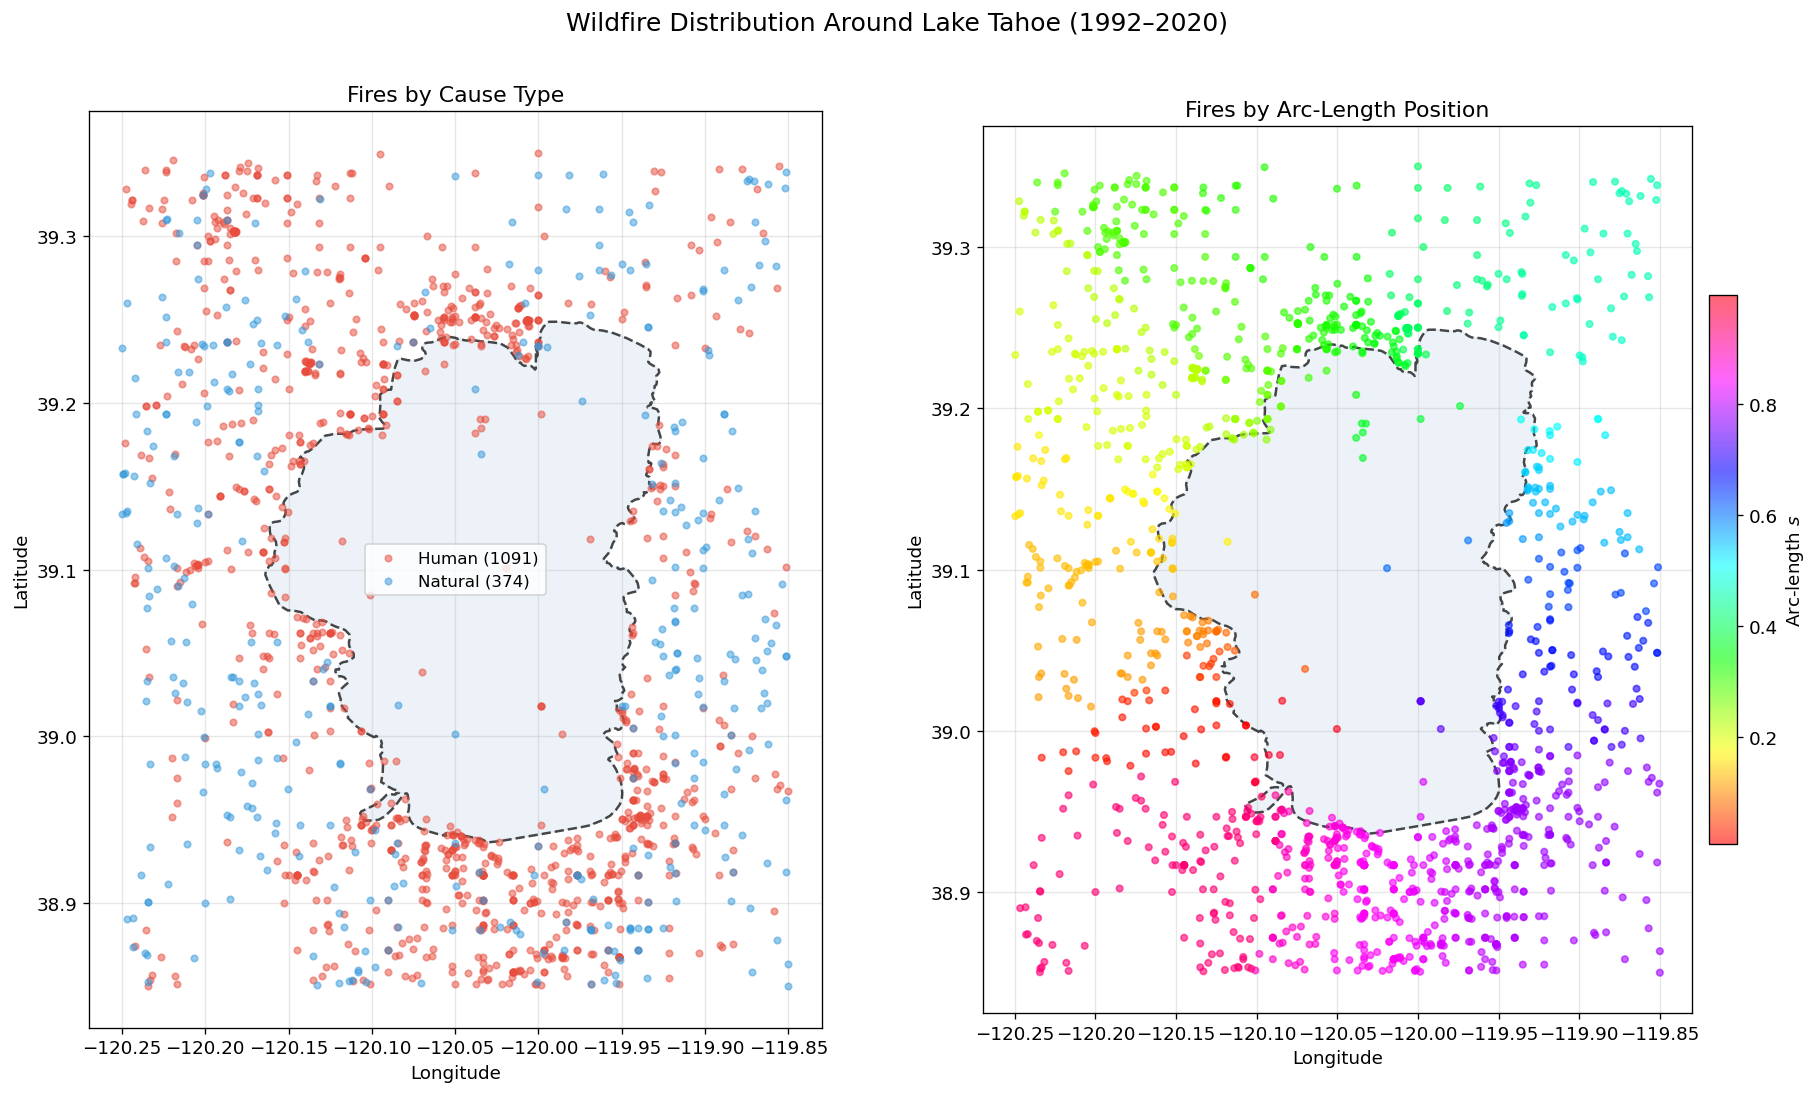

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# --- By cause ---
ax = axes[0]
ax.plot(spline_pts[:, 0], spline_pts[:, 1], 'k--', linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

natural = fires[fires['cause_binary'] == 0]
human = fires[fires['cause_binary'] == 1]

ax.scatter(human['LONGITUDE'], human['LATITUDE'],
           c='#e74c3c', s=15, alpha=0.5, label=f'Human ({len(human)})', zorder=3)
ax.scatter(natural['LONGITUDE'], natural['LATITUDE'],
           c='#3498db', s=15, alpha=0.5, label=f'Natural ({len(natural)})', zorder=3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Fires by Cause Type')
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- By arc-length position ---
ax = axes[1]
scatter = ax.scatter(fires['LONGITUDE'], fires['LATITUDE'],
                     c=fires['s_param'], cmap='hsv', s=15, alpha=0.6, zorder=3)
ax.plot(spline_pts[:, 0], spline_pts[:, 1], 'k--', linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
plt.colorbar(scatter, ax=ax, label='Arc-length $s$', shrink=0.6, aspect=20, pad=0.02)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Fires by Arc-Length Position')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.suptitle('Wildfire Distribution Around Lake Tahoe (1992–2020)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 6. Standard k-Means (Baseline)

As a baseline, we run standard k-Means using only the geographic coordinates $(x, y)$. This ignores the lake as an obstacle and ignores fire attributes entirely.

In [9]:
# Standard k-Means on (x, y) only
k = 3
kmeans_standard = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_standard = kmeans_standard.fit_predict(xy_scaled)

print(f'Standard k-Means converged in {kmeans_standard.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    n = np.sum(labels_standard == i)
    print(f'  Cluster {i+1}: {n} fires')

Standard k-Means converged in 6 iterations

Cluster sizes:
  Cluster 1: 476 fires
  Cluster 2: 690 fires
  Cluster 3: 299 fires


c:\Users\mpp24\anaconda3\envs\obstacle-clustering\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


C:\Users\mpp24\AppData\Local\Temp\ipykernel_41768\2898688573.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', k)


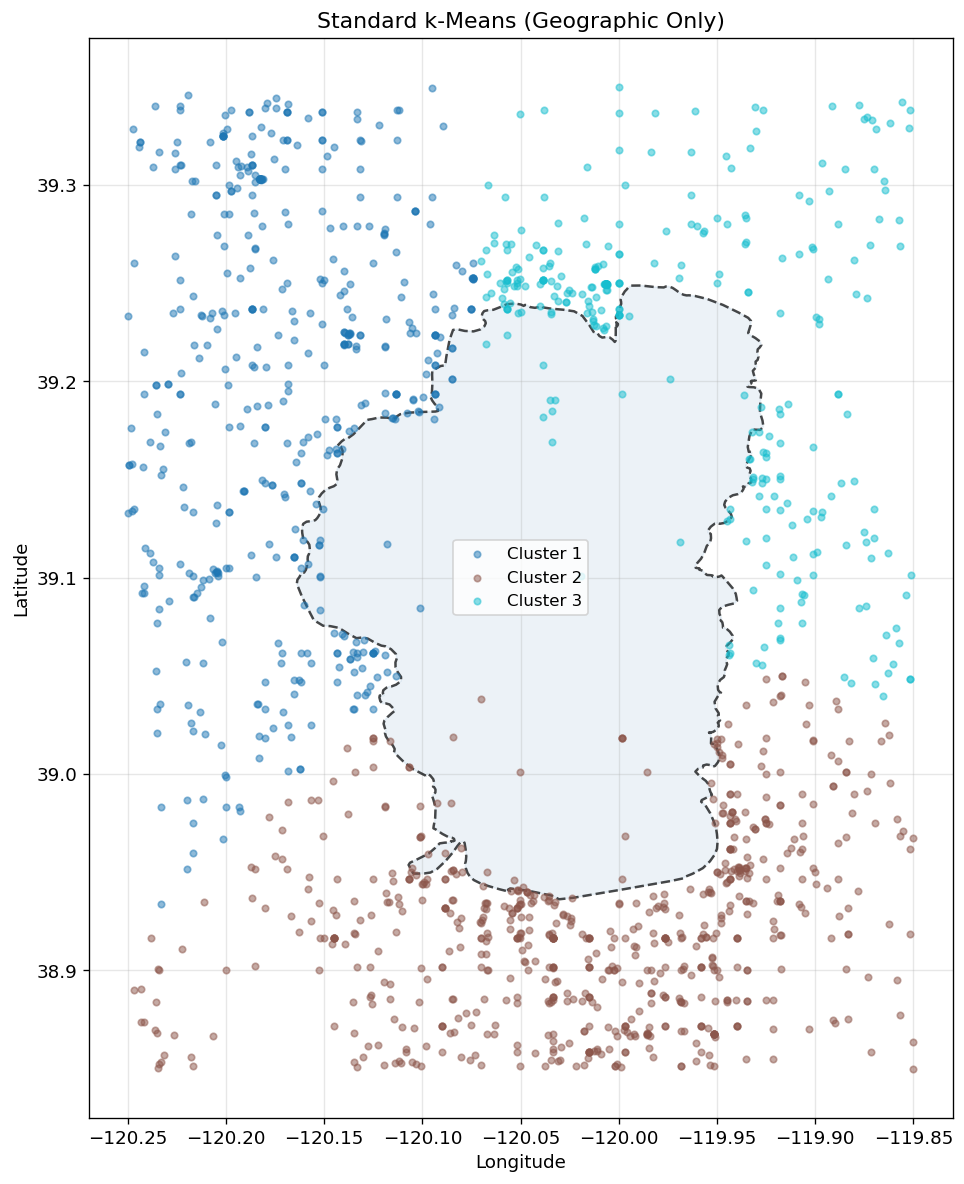


Baseline attribute separation (sigma_a): 0.3333


In [10]:
# Plot standard k-Means results
fig, ax = plt.subplots(figsize=(10, 10))

colors = cm.get_cmap('tab10', k)
for i in range(k):
    mask = labels_standard == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=[colors(i)], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], 'k--', linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Standard k-Means (Geographic Only)')
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check attribute separation for baseline
sigma_std, details_std = attribute_separation(
    X, labels_standard, k, attr_indices=[3, 4]
)
print(f'\nBaseline attribute separation (sigma_a): {sigma_std:.4f}')

### Choosing k: Elbow Method

Before proceeding with the obstacle-aware algorithm, we use the elbow method to inform our choice of $k$. This plots the total within-cluster sum of squared distances (inertia) for a range of $k$ values. A good $k$ is where the curve bends — adding more clusters beyond that point yields diminishing returns.

We run this on standard k-Means (fast) rather than the obstacle-aware version, since the underlying cluster structure is what we're assessing.

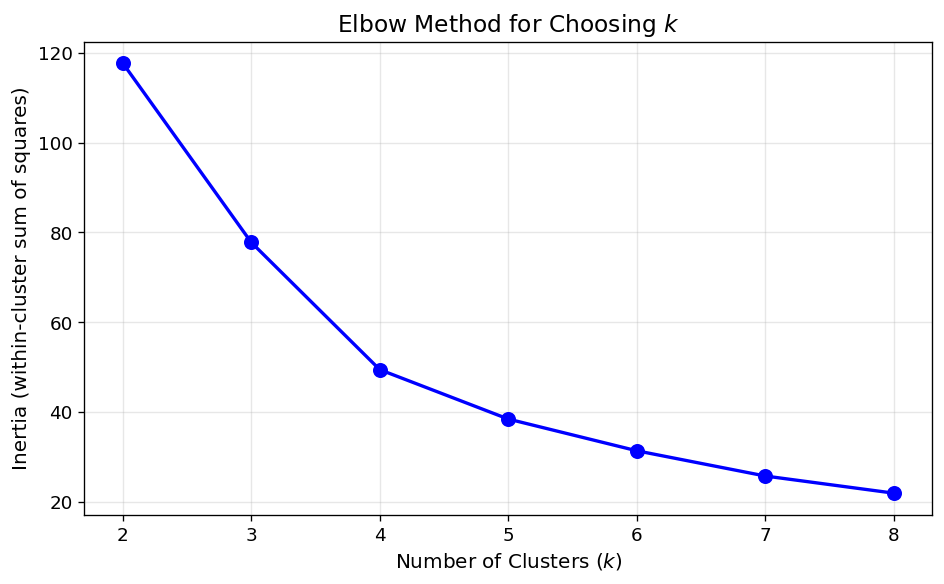

Inertia by k:
  k=2: 117.7308
  k=3: 77.7684
  k=4: 49.4114
  k=5: 38.4030
  k=6: 31.3317
  k=7: 25.7065
  k=8: 21.8872


In [11]:
# Elbow method: test k = 2 through 8
k_range = range(2, 9)
inertias = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    km.fit(xy_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters ($k$)', fontsize=12)
ax.set_ylabel('Inertia (within-cluster sum of squares)', fontsize=12)
ax.set_title('Elbow Method for Choosing $k$', fontsize=14)
ax.set_xticks(list(k_range))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the values for reference
print('Inertia by k:')
for k_test, inertia in zip(k_range, inertias):
    print(f'  k={k_test}: {inertia:.4f}')

The elbow method suggests k=3 or k=4. We use k=3 for consistency with the toy problem and because it aligns with the natural jurisdictional and geographic divisions around Lake Tahoe — the California west shore, the Nevada east shore, and the south shore urban interface

---

# TIER 1: Spatial-Only Comparison

**Goal**: Isolate the effect of the arc-length parameter $s$ on clustering quality, without attributes.

We compare three approaches, all using $\gamma = 0$ (no attributes):
1. Standard k-Means on $(x, y)$ — the baseline (already computed above)
2. Obstacle-aware k-Means on $(x, y, s)$ with $\alpha = 1, \beta = 1$ — equal weights
3. Obstacle-aware k-Means on $(x, y, s)$ with optimized $\beta$ — tuned via simulated annealing

## 7. Spatial-Only Feature Matrix

In [12]:
# Tier 1 feature matrix: [x_scaled, y_scaled, s] — no attributes
X_spatial = np.column_stack([
    xy_scaled,                          # columns 0, 1: geographic
    fires['s_param'].values,            # column 2: arc-length
])

print(f'Tier 1 feature matrix shape: {X_spatial.shape}')
print(f'Features: x_scaled, y_scaled, s')

Tier 1 feature matrix shape: (1465, 3)
Features: x_scaled, y_scaled, s


## 8. Tier 1: Obstacle-Aware k-Means (Equal Weights)

We run the obstacle-aware algorithm with $\alpha = 1, \beta = 1, \gamma = 0$. This gives geography and arc-length equal influence, with no attribute component.

In [13]:
# Obstacle-aware k-Means: spatial only, equal weights
model_t1_equal = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,
    random_state=42, n_attr=0
)
model_t1_equal.fit(X_spatial, t_data=fires['t_param'].values)
labels_t1_equal = model_t1_equal.labels_

print(f'Tier 1 equal weights: converged in {model_t1_equal.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t1_equal == i)} fires')

Tier 1 equal weights: converged in 5 iterations

Cluster sizes:
  Cluster 1: 607 fires
  Cluster 2: 316 fires
  Cluster 3: 542 fires


## 9. Tier 1: Optimizing $\beta$

With $\alpha = 1$ fixed and $\gamma = 0$ (no attributes), we optimize a single parameter: $\beta$, the arc-length weight. This is a 1D optimization, so it converges quickly.

Since there are no attributes, the objective simplifies to $J = \bar{\rho}$ — we're purely minimizing within-cluster spatial distortion.

In [14]:
# 1D optimization: find optimal beta with alpha=1, gamma=0
alpha_fixed = 1.0

def objective_t1(params):
    """Objective for Tier 1: optimize beta only, gamma=0."""
    beta = params[0]
    return objective_function(
        (alpha_fixed, beta, 0.0),
        X_spatial, fires['t_param'].values, boundary,
        k=k, n_attr=0, attr_indices=[], random_state=42
    )

def progress_callback(x, f, context):
    print(f'  beta={x[0]:.4f}, J={f:.4f}')

print('Tier 1: Optimizing beta (alpha=1.0, gamma=0.0)...')

sa_t1 = dual_annealing(
    objective_t1,
    bounds=[(0, 2)],
    seed=42,
    maxiter=100,
    callback=progress_callback
)

opt_beta_t1 = sa_t1.x[0]

# Refit with optimal beta
model_t1_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=alpha_fixed, beta=opt_beta_t1, gamma=0.0,
    random_state=42, n_attr=0
)
model_t1_opt.fit(X_spatial, t_data=fires['t_param'].values)
labels_t1_opt = model_t1_opt.labels_

print(f'\nOptimal beta: {opt_beta_t1:.4f}')
print(f'Objective (rho_bar): {sa_t1.fun:.4f}')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t1_opt == i)} fires')

Tier 1: Optimizing beta (alpha=1.0, gamma=0.0)...
  beta=1.5323, J=1.0585
  beta=1.4923, J=1.0584
  beta=1.8207, J=1.0583
  beta=1.7112, J=1.0583

Optimal beta: 1.7112
Objective (rho_bar): 1.0583

Cluster sizes:
  Cluster 1: 285 fires
  Cluster 2: 718 fires
  Cluster 3: 462 fires


## 10. Tier 1: Evaluating Spatial Coherence

Since $\bar{\rho}$ is computed differently for standard k-Means (which doesn't use $s$) and obstacle-aware k-Means (which does), we need a metric that can be applied fairly to any method's cluster labels.

**Arc-length span**: For each cluster, we compute the loop-aware range of $s$ values — the length of the shortest arc on the boundary that contains all cluster members' projected positions. A spatially coherent cluster around the lake should span a small arc (points on the same side), while a cluster that reaches across the lake will span a large arc. This metric is computed identically regardless of which method produced the labels.

In [15]:
from obstacle_clustering import loop_aware_distance

def arc_length_span(s_values):
    """
    Compute the smallest arc on [0,1] that contains all s values.
    
    For circular data, we can't just take max-min. Instead, we sort 
    the values, compute the gaps between consecutive points (including
    the wrap-around gap), and the span is 1 minus the largest gap.
    """
    if len(s_values) <= 1:
        return 0.0
    s_sorted = np.sort(s_values % 1.0)
    gaps = np.diff(s_sorted)
    wrap_gap = (1.0 - s_sorted[-1]) + s_sorted[0]  # gap across the seam
    all_gaps = np.append(gaps, wrap_gap)
    return 1.0 - np.max(all_gaps)

# Compute arc-length span for each method
methods = {
    'Standard k-Means': labels_standard,
    'Obstacle-Aware (equal)': labels_t1_equal,
    f'Obstacle-Aware (opt, beta={opt_beta_t1:.2f})': labels_t1_opt,
}

print('Arc-length span by cluster (lower = more spatially coherent):')
print(f'{"Method":<40} {"Cl 1":>8} {"Cl 2":>8} {"Cl 3":>8} {"Mean":>8}')
print('-' * 72)

for name, labels in methods.items():
    spans = []
    for i in range(k):
        s_vals = fires['s_param'].values[labels == i]
        span = arc_length_span(s_vals)
        spans.append(span)
    mean_span = np.mean(spans)
    print(f'{name:<40} {spans[0]:>8.3f} {spans[1]:>8.3f} {spans[2]:>8.3f} {mean_span:>8.3f}')

Arc-length span by cluster (lower = more spatially coherent):
Method                                       Cl 1     Cl 2     Cl 3     Mean
------------------------------------------------------------------------
Standard k-Means                            0.385    0.391    0.368    0.381
Obstacle-Aware (equal)                      0.364    0.344    0.279    0.329
Obstacle-Aware (opt, beta=1.71)             0.330    0.391    0.297    0.339


## 11. Tier 1: Visual Comparison

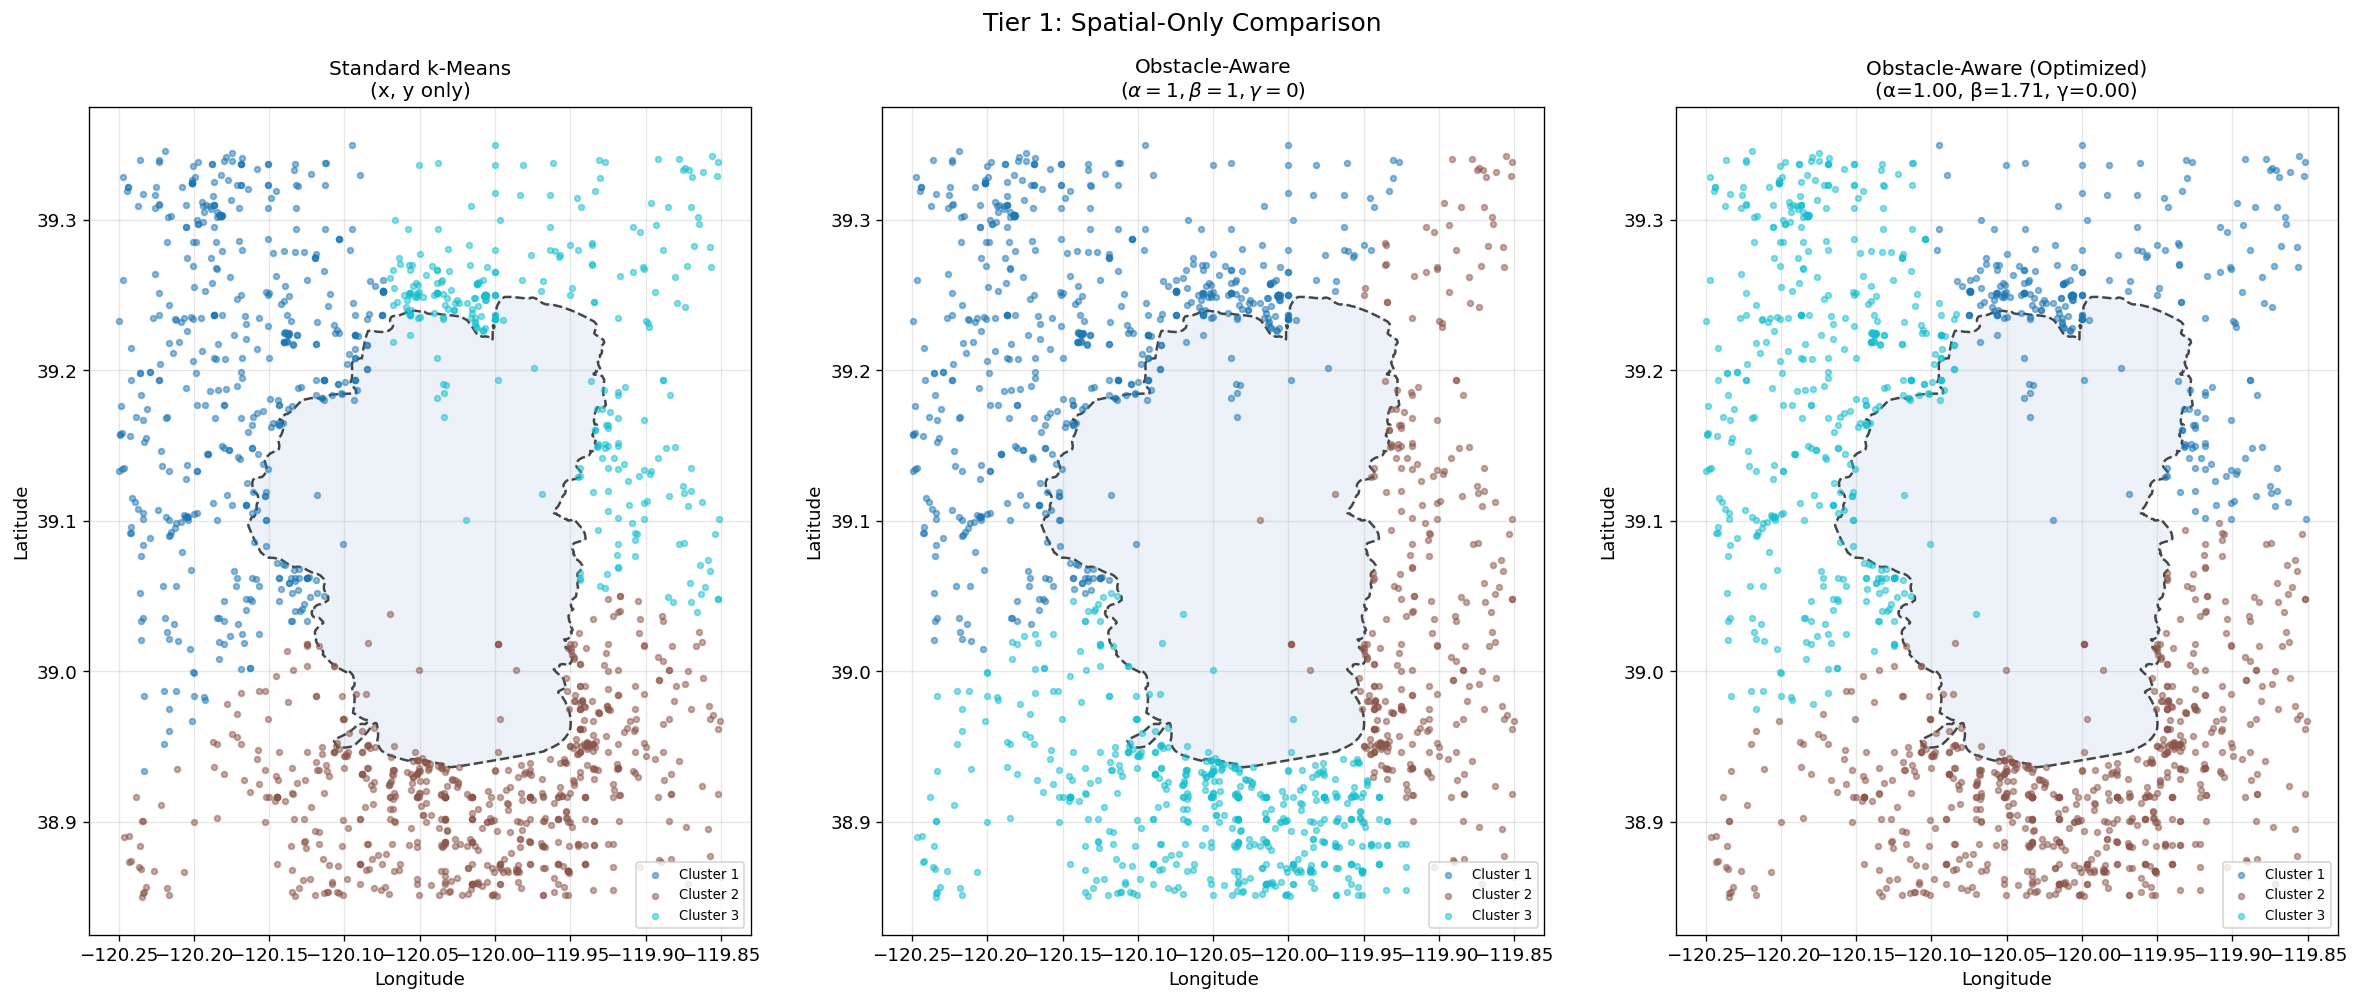

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

t1_titles = [
    'Standard k-Means\n(x, y only)',
    r'Obstacle-Aware' + '\n' + r'($\alpha=1, \beta=1, \gamma=0$)',
    f'Obstacle-Aware (Optimized)\n' + f'(\u03b1=1.00, \u03b2={opt_beta_t1:.2f}, \u03b3=0.00)'
]
t1_labels = [labels_standard, labels_t1_equal, labels_t1_opt]

for col, (labels, title) in enumerate(zip(t1_labels, t1_titles)):
    ax = axes[col]
    for i in range(k):
        mask = labels == i
        ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
                   c=[colors(i)], s=12, alpha=0.5, label=f'Cluster {i+1}', zorder=3)
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], 'k--', linewidth=1.5, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tier 1: Spatial-Only Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 12. Tier 1: Summary

The arc-length span metric and the side-by-side maps above demonstrate whether the obstacle-aware algorithm produces clusters that better respect the lake boundary compared to standard k-Means. A lower mean arc-length span means the clusters are more spatially contiguous around the shoreline — fires in each zone are on the same side of the lake.

---

# TIER 2: Spatial + Attribute Comparison

**Goal**: Show that the framework extends to incorporate fire attributes (size and cause), creating clusters that are both spatially coherent and behaviorally distinct.

We compare:
1. Standard k-Means on $(x, y, \text{fire\_size}, \text{cause})$ — baseline with attributes but no arc-length
2. Obstacle-aware k-Means on $(x, y, s, \text{fire\_size}, \text{cause})$ with equal weights
3. Obstacle-aware k-Means with optimized weights ($\alpha = 1$, optimize $\beta$ and $\gamma$)

## 13. Tier 2: Standard k-Means with Attributes

In [17]:
# Standard k-Means baseline for Tier 2: (x, y, fire_size, cause) — no s
X_std_attr = np.column_stack([
    xy_scaled,
    fire_size_scaled.ravel(),
    fires['cause_binary'].values
])

kmeans_t2_std = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_t2_std = kmeans_t2_std.fit_predict(X_std_attr)

print(f'Tier 2 standard k-Means (with attributes, no s):')
print(f'Cluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_std == i)} fires')

sigma_t2_std, _ = attribute_separation(X, labels_t2_std, k, attr_indices=[3, 4])
print(f'\nAttribute separation (sigma_a): {sigma_t2_std:.4f}')

Tier 2 standard k-Means (with attributes, no s):
Cluster sizes:
  Cluster 1: 374 fires
  Cluster 2: 565 fires
  Cluster 3: 526 fires

Attribute separation (sigma_a): 0.3333


## 14. Tier 2: Obstacle-Aware with Attributes (Equal Weights)

Now we use the full feature vector $(x, y, s, \text{fire\_size}, \text{cause})$ with $\alpha = \beta = \gamma = 1$.

In [18]:
# Obstacle-aware k-Means: full features, equal weights
model_t2_equal = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=1.0,
    random_state=42, n_attr=2
)
model_t2_equal.fit(X, t_data=fires['t_param'].values)
labels_t2_equal = model_t2_equal.labels_

sigma_t2_eq, _ = attribute_separation(X, labels_t2_equal, k, attr_indices=[3, 4])

print(f'Tier 2 obstacle-aware (equal weights):')
print(f'rho_bar: {model_t2_equal.rho_bar_:.4f}')
print(f'sigma_a: {sigma_t2_eq:.4f}')
print(f'J: {model_t2_equal.rho_bar_ + (1 - sigma_t2_eq):.4f}')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_equal == i)} fires')

Tier 2 obstacle-aware (equal weights):
rho_bar: 0.1405
sigma_a: 0.3333
J: 0.8072

Cluster sizes:
  Cluster 1: 522 fires
  Cluster 2: 374 fires
  Cluster 3: 569 fires


## 15. Tier 2: Optimizing $\beta$ and $\gamma$

With $\alpha = 1$ fixed, we optimize $\beta \in [0, 2]$ and $\gamma \in [0, 1]$. The $\gamma$ cap ensures attributes inform the clustering without overriding the spatial structure — reflecting our goal of defining *geographic* management zones with distinct fire behavior profiles.

**Note**: This cell may take 30-60 minutes.

In [19]:
# 2D optimization: beta and gamma, alpha=1 fixed
def objective_t2(params):
    """Objective for Tier 2: optimize (beta, gamma)."""
    beta, gamma = params
    return objective_function(
        (alpha_fixed, beta, gamma),
        X, fires['t_param'].values, boundary,
        k=k, n_attr=2, attr_indices=[3, 4], random_state=42
    )

def progress_callback_t2(x, f, context):
    print(f'  beta={x[0]:.4f}, gamma={x[1]:.4f}, J={f:.4f}')

print('Tier 2: Optimizing beta and gamma (alpha=1.0 fixed)...')

sa_t2 = dual_annealing(
    objective_t2,
    bounds=[(0, 2), (0, 1)],
    seed=42,
    maxiter=100,
    callback=progress_callback_t2
)

opt_beta_t2 = sa_t2.x[0]
opt_gamma_t2 = sa_t2.x[1]

# Refit with optimal weights
model_t2_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=alpha_fixed, beta=opt_beta_t2, gamma=opt_gamma_t2,
    random_state=42, n_attr=2
)
model_t2_opt.fit(X, t_data=fires['t_param'].values)
labels_t2_opt = model_t2_opt.labels_

sigma_t2_opt, _ = attribute_separation(X, labels_t2_opt, k, attr_indices=[3, 4])

print(f'\nOptimization complete!')
print(f'  alpha (fixed): {alpha_fixed:.4f}')
print(f'  Optimal beta:  {opt_beta_t2:.4f}')
print(f'  Optimal gamma: {opt_gamma_t2:.4f}')
print(f'  Objective J:   {sa_t2.fun:.4f}')
print(f'  rho_bar:       {model_t2_opt.rho_bar_:.4f}')
print(f'  sigma_a:       {sigma_t2_opt:.4f}')

Tier 2: Optimizing beta and gamma (alpha=1.0 fixed)...
  beta=0.1017, gamma=0.5090, J=0.7294
  beta=0.1669, gamma=0.3697, J=0.7291
  beta=0.8943, gamma=0.3749, J=0.7279
  beta=1.8638, gamma=0.3420, J=0.7271
  beta=1.7834, gamma=0.6426, J=0.6135
  beta=0.9644, gamma=0.5559, J=0.5713
  beta=1.2023, gamma=0.5559, J=0.5687
  beta=1.3741, gamma=0.6548, J=0.4486
  beta=1.1569, gamma=0.5725, J=0.4480
  beta=1.6631, gamma=0.6418, J=0.4443

Optimization complete!
  alpha (fixed): 1.0000
  Optimal beta:  1.6631
  Optimal gamma: 0.6418
  Objective J:   0.4443
  rho_bar:       0.1110
  sigma_a:       0.6667


## 16. Tier 2: Cluster Profiles (Optimized)

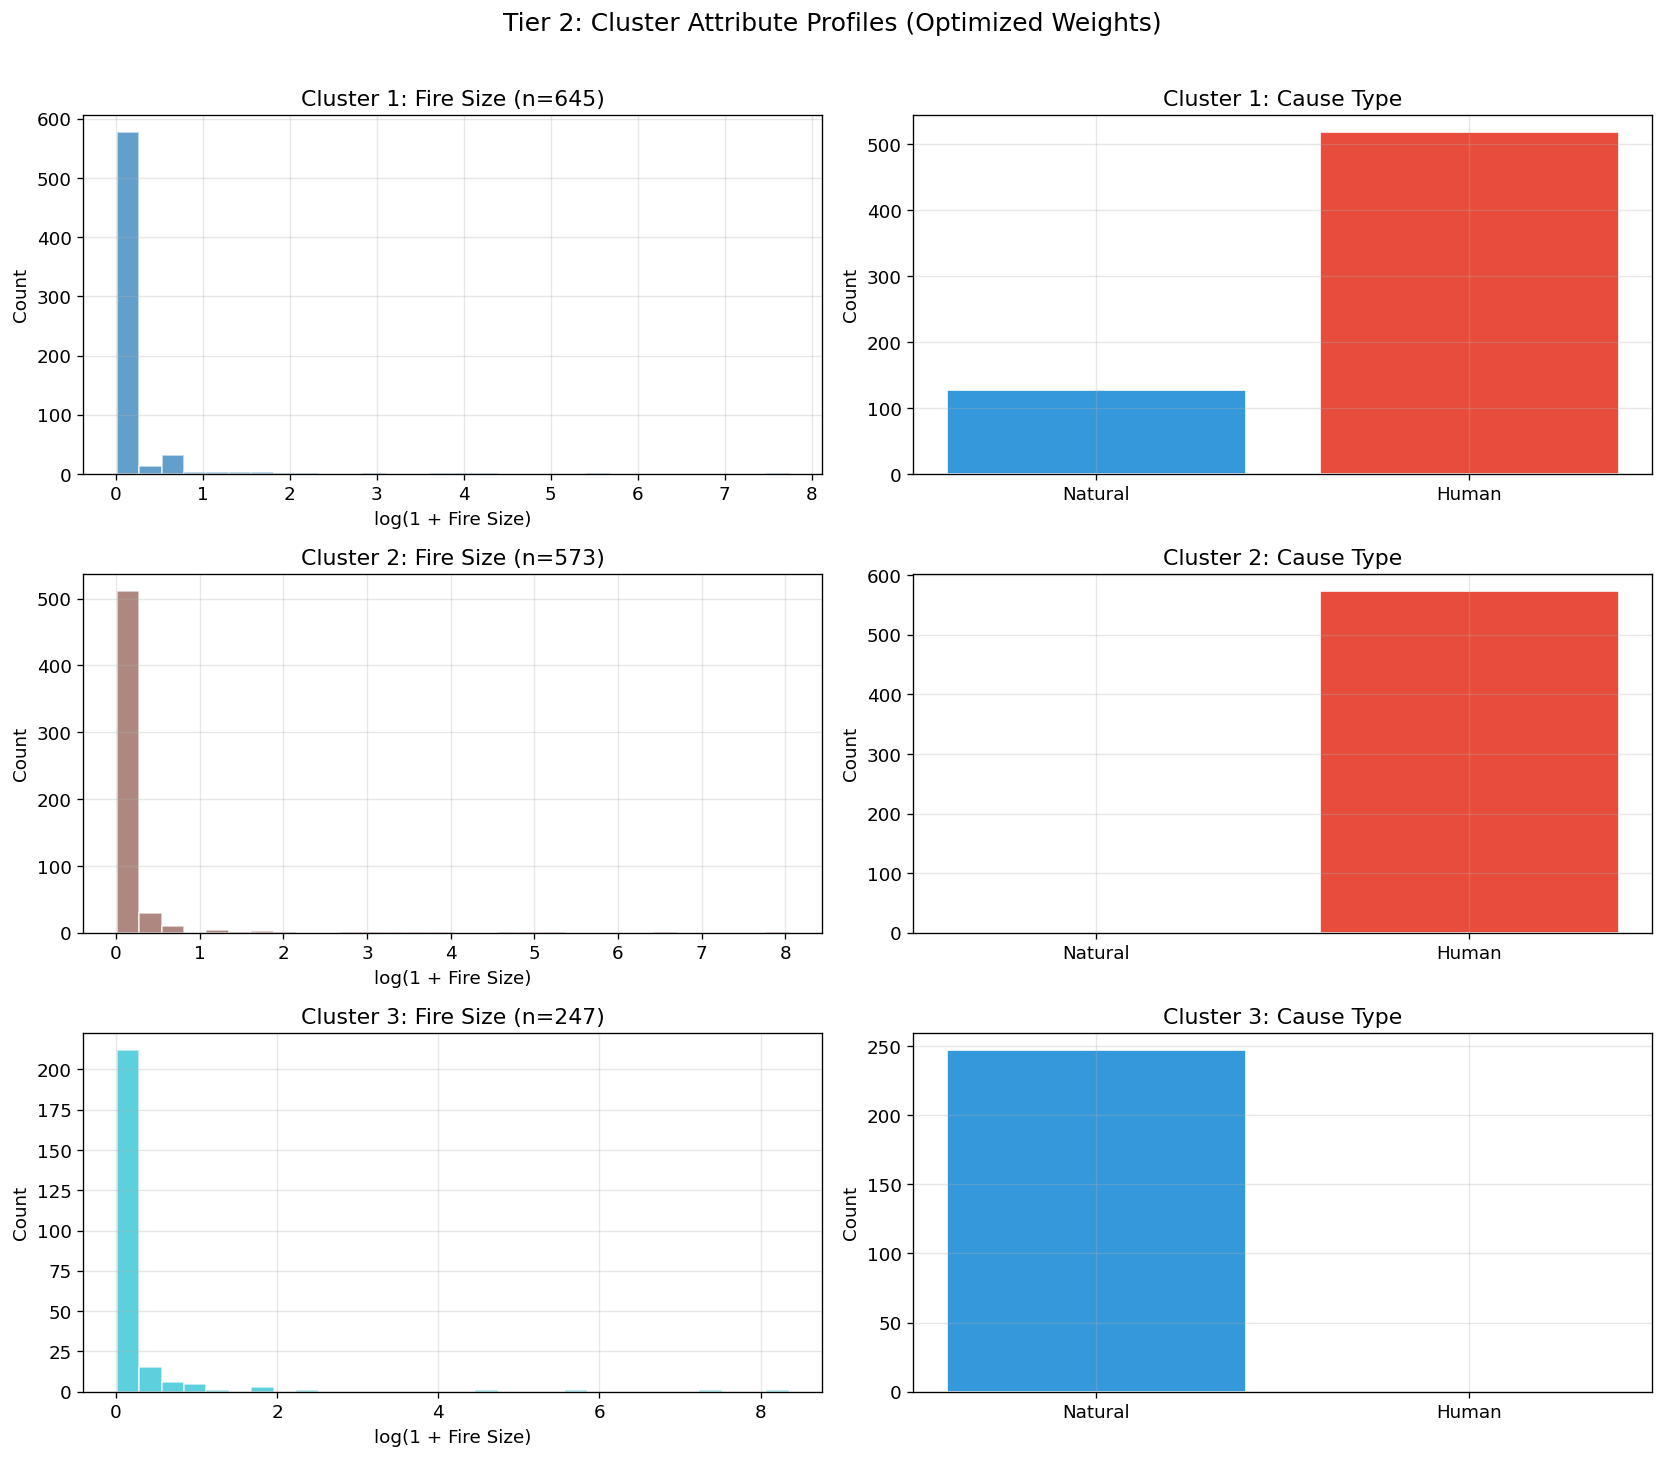

Tier 2 optimized cluster summary:
Cluster    Size     Mean Fire Size   % Natural    Mean s    
--------------------------------------------------------
1          645      4.49             19.7         0.268     
2          573      7.85             0.0          0.795     
3          247      25.72            100.0        0.682     


In [20]:
fires['cluster_t2_opt'] = labels_t2_opt

fig, axes = plt.subplots(k, 2, figsize=(14, 4 * k))

for i in range(k):
    cluster = fires[fires['cluster_t2_opt'] == i]

    # Fire size distribution
    ax = axes[i, 0]
    ax.hist(cluster['fire_size_log'], bins=30, color=colors(i),
            edgecolor='white', alpha=0.7)
    ax.set_xlabel('log(1 + Fire Size)')
    ax.set_ylabel('Count')
    ax.set_title(f'Cluster {i+1}: Fire Size (n={len(cluster)})')
    ax.grid(True, alpha=0.3)

    # Cause breakdown
    ax = axes[i, 1]
    cause_counts = cluster['cause_binary'].value_counts().sort_index()
    labels_cause = ['Natural', 'Human']
    bar_colors = ['#3498db', '#e74c3c']
    bars = ax.bar(labels_cause, [cause_counts.get(0, 0), cause_counts.get(1, 0)],
                  color=bar_colors, edgecolor='white')
    ax.set_ylabel('Count')
    ax.set_title(f'Cluster {i+1}: Cause Type')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tier 2: Cluster Attribute Profiles (Optimized Weights)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print('Tier 2 optimized cluster summary:')
print(f'{"Cluster":<10} {"Size":<8} {"Mean Fire Size":<16} {"% Natural":<12} {"Mean s":<10}')
print('-' * 56)
for i in range(k):
    cluster = fires[fires['cluster_t2_opt'] == i]
    print(f'{i+1:<10} {len(cluster):<8} '
          f'{cluster["FIRE_SIZE"].mean():<16.2f} '
          f'{(cluster["cause_binary"] == 0).mean() * 100:<12.1f} '
          f'{cluster["s_param"].mean():<10.3f}')

## 17. Tier 2: Visual Comparison

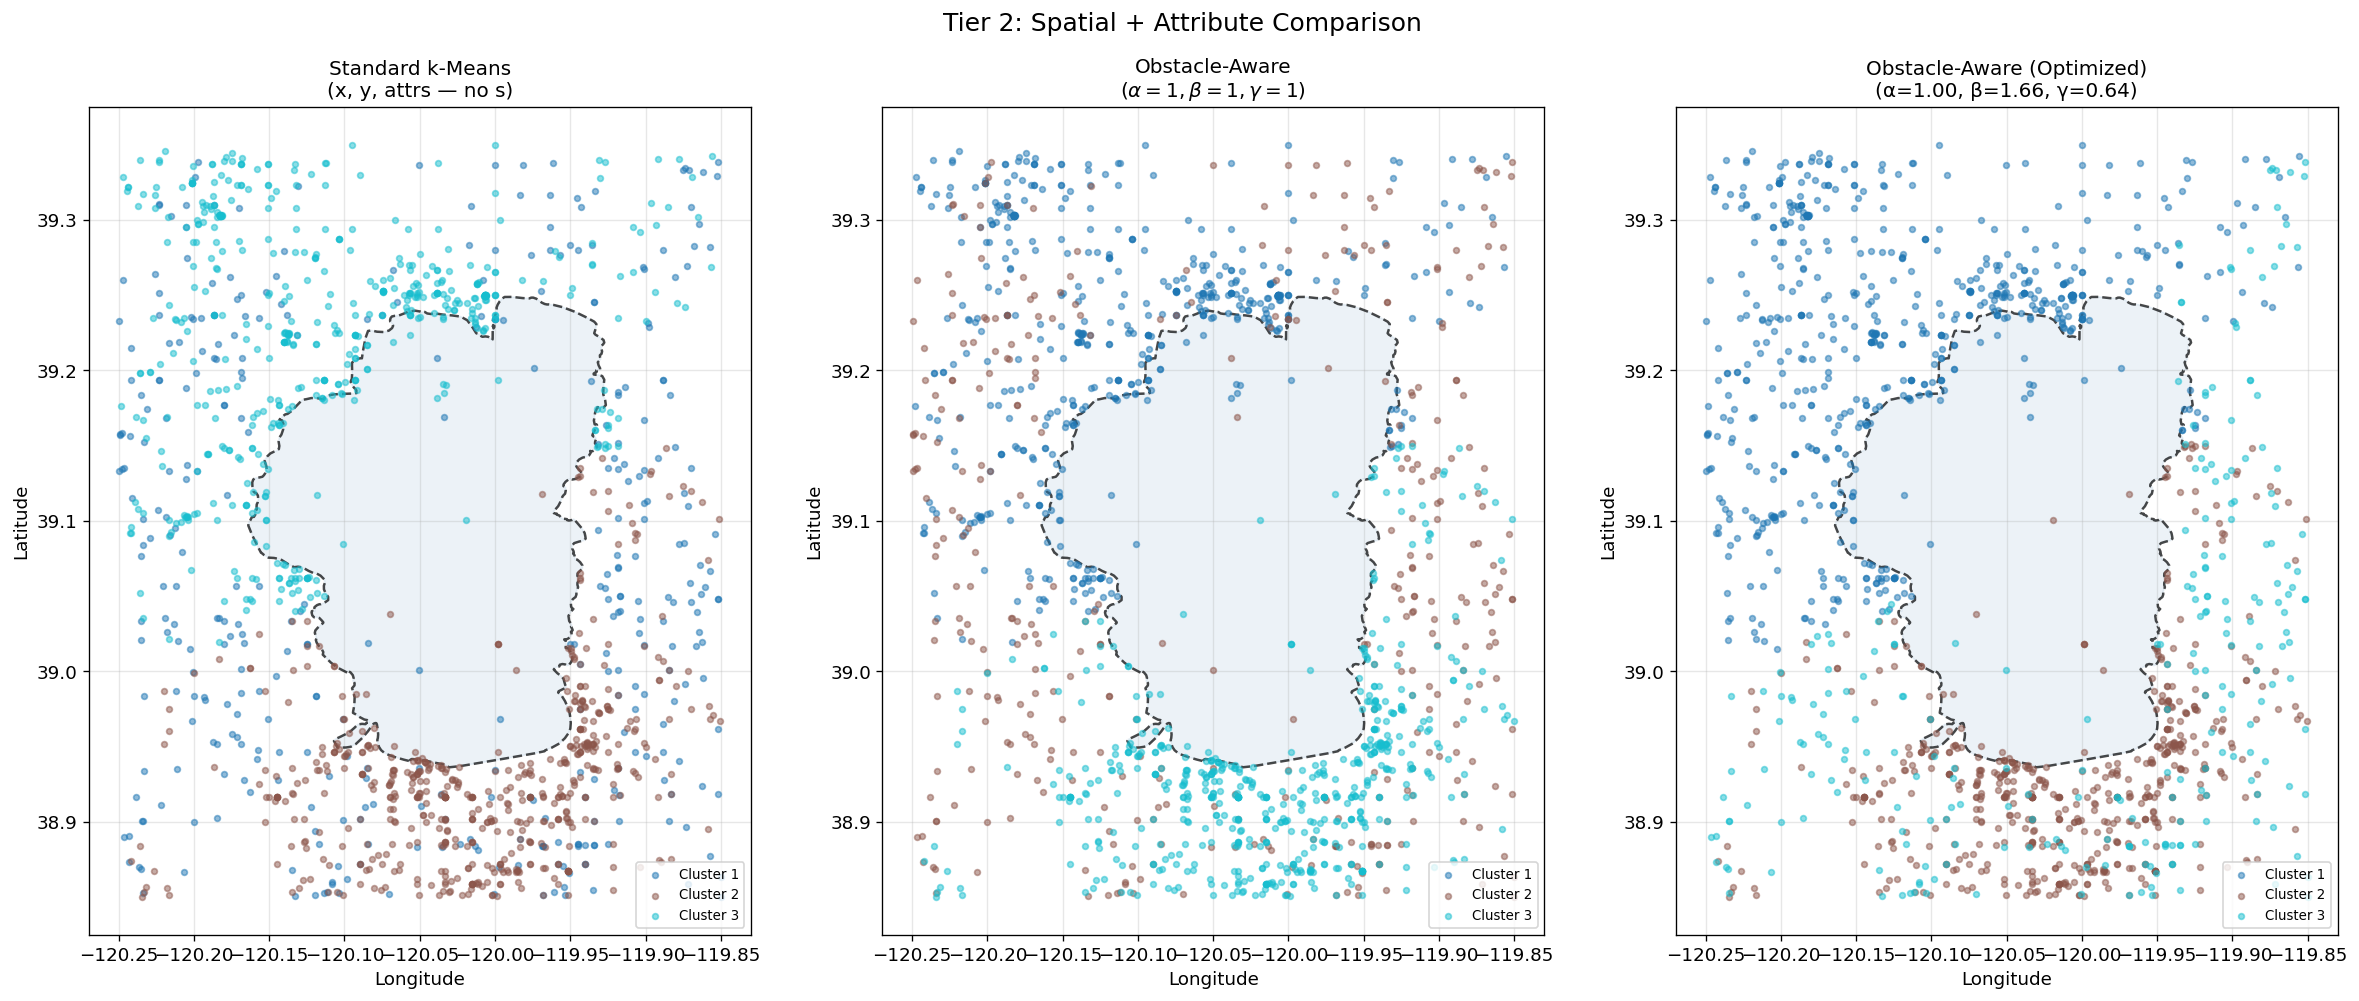

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

t2_titles = [
    'Standard k-Means\n(x, y, attrs — no s)',
    r'Obstacle-Aware' + '\n' + r'($\alpha=1, \beta=1, \gamma=1$)',
    f'Obstacle-Aware (Optimized)\n'
    f'(\u03b1=1.00, \u03b2={opt_beta_t2:.2f}, \u03b3={opt_gamma_t2:.2f})'
]
t2_labels = [labels_t2_std, labels_t2_equal, labels_t2_opt]

for col, (labels, title) in enumerate(zip(t2_labels, t2_titles)):
    ax = axes[col]
    for i in range(k):
        mask = labels == i
        ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
                   c=[colors(i)], s=12, alpha=0.5, label=f'Cluster {i+1}', zorder=3)
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], 'k--', linewidth=1.5, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tier 2: Spatial + Attribute Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 18. Tier 2: Quantitative Comparison

For Tier 2, $\sigma_a$ is computed identically across all methods (same attribute columns, same statistical tests), making it a fair comparison. We also include the arc-length span metric from Tier 1 to see whether adding attributes affects spatial coherence.

In [22]:
# Arc-length spans for Tier 2
t2_methods = {
    'Std k-Means (x,y,attrs)': labels_t2_std,
    'Obstacle-Aware (equal)': labels_t2_equal,
    f'Obstacle-Aware (optimized)': labels_t2_opt,
}

# Attribute separation
sigma_t2_std_val, _ = attribute_separation(X, labels_t2_std, k, attr_indices=[3, 4])
sigma_t2_eq_val, _ = attribute_separation(X, labels_t2_equal, k, attr_indices=[3, 4])
sigma_t2_opt_val, _ = attribute_separation(X, labels_t2_opt, k, attr_indices=[3, 4])

print('Tier 2 quantitative comparison:')
print(f'{"Method":<35} {"sigma_a":>10} {"Mean Arc Span":>15}')
print('-' * 62)

for (name, labels), sigma in zip(t2_methods.items(), 
                                   [sigma_t2_std_val, sigma_t2_eq_val, sigma_t2_opt_val]):
    spans = [arc_length_span(fires['s_param'].values[labels == i]) for i in range(k)]
    mean_span = np.mean(spans)
    print(f'{name:<35} {sigma:>10.4f} {mean_span:>15.3f}')

Tier 2 quantitative comparison:
Method                                 sigma_a   Mean Arc Span
--------------------------------------------------------------
Std k-Means (x,y,attrs)                 0.3333           0.672
Obstacle-Aware (equal)                  0.3333           0.654
Obstacle-Aware (optimized)              0.6667           0.536


## 19. Saving Results

We save the clustered fire data with labels from both tiers for use in Notebook 04.

In [ ]:
# Save clustered fire data
fires['cluster_t1_equal'] = labels_t1_equal
fires['cluster_t1_opt'] = labels_t1_opt
fires['cluster_t2_std'] = labels_t2_std
fires['cluster_t2_equal'] = labels_t2_equal
fires['cluster_t2_opt'] = labels_t2_opt

output_cols = ['LATITUDE', 'LONGITUDE', 'FIRE_SIZE', 'NWCG_GENERAL_CAUSE',
               'cause_binary', 'FIRE_YEAR', 'DISCOVERY_DOY',
               't_param', 's_param', 'fire_size_log',
               'cluster_t1_equal', 'cluster_t1_opt',
               'cluster_t2_std', 'cluster_t2_equal', 'cluster_t2_opt']
fires[output_cols].to_csv('../data/processed/tahoe_fires_clustered.csv', index=False)

# Save optimal parameters
import json as json_lib
opt_params = {
    'tier1': {
        'alpha': alpha_fixed,
        'beta': opt_beta_t1,
        'gamma': 0.0,
        'rho_bar': model_t1_opt.rho_bar_,
    },
    'tier2': {
        'alpha': alpha_fixed,
        'beta': opt_beta_t2,
        'gamma': opt_gamma_t2,
        'objective': sa_t2.fun,
        'rho_bar': model_t2_opt.rho_bar_,
        'sigma_a': sigma_t2_opt,
    },
    'k': k,
    'n_fires': len(fires),
}
with open('../data/processed/optimal_params.json', 'w') as f:
    json_lib.dump(opt_params, f, indent=2)

print(f'Saved {len(fires)} clustered fires to data/processed/tahoe_fires_clustered.csv')
print(f'Saved optimal parameters to data/processed/optimal_params.json')

## 20. Discussion

### Tier 1: The Arc-Length Parameter

The spatial-only comparison isolates the core contribution of this project: the arc-length parameter $s$. Standard k-Means treats the space around Lake Tahoe as if the lake doesn't exist — fires on opposite sides can be assigned to the same cluster if they're close in Euclidean distance. The obstacle-aware algorithm uses $s$ to encode each fire's position along the shoreline, so fires separated by the lake receive different assignments even if they're geographically close.

The **arc-length span metric** provides a fair quantitative comparison: it measures the same thing (how much of the shoreline each cluster covers) regardless of which method produced the labels. Lower mean span means more spatially contiguous zones.

### Tier 2: Adding Attributes

The dual-domain analysis shows that the framework extends naturally to incorporate fire attributes. The key design choice — constraining $\gamma \leq 1$ so that $\gamma \leq \alpha$ — ensures that attributes *inform* the clustering without overriding the spatial structure. This reflects the application goal: we want *geographic* management zones that happen to have distinct fire behavior profiles, not attribute-based groupings that lack spatial coherence.

### Methodological Notes

- **Weight normalization**: We fix $\alpha = 1$ without loss of generality, since only the ratios between weights affect cluster assignments. This eliminates a redundant degree of freedom from the optimization.

- **Boundary choice**: We use the lake shoreline as the obstacle boundary. The road network follows a similar path and would produce comparable arc-length orderings — see Notebook 02 for discussion.

- **Fire size transformation**: We use $\log(1 + \text{fire size})$ because fire sizes span several orders of magnitude. The log transformation prevents rare large fires from dominating the distance metric.

- **Cause encoding**: The binary Natural/Human classification captures the most important management distinction from the NWCG cause categories.

### Key Files Produced

| File | Description |
|------|-------------|
| `data/processed/tahoe_fires_clustered.csv` | Fire records with cluster labels from all comparisons |
| `data/processed/optimal_params.json` | Optimal weights and performance metrics for both tiers |